# Car AI Project - Training Trees

## 1. Libraries

In [0]:
# Core
import numpy as np
import pandas as pd

# Plot
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

# Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# GridSearch
from sklearn.model_selection import GridSearchCV

# Pipeline
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load objects
import joblib

# MLflow
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

In [0]:
# Import project configuration
import sys
import os

# Add parent directory to path to import config
sys.path.append("..")
from config import *

print("PROJECT CONFIGURATION LOADED")
print(f"\nBASE_PATH: {BASE_PATH}")
print(f"\nData Paths:")
print(f"   - RAW_DATA_PATH: {RAW_DATA_PATH}")
print(f"   - FEATURES_PATH: {FEATURES_PATH}")
print(f"   - PROCESSED_DATA_PATH: {PROCESSED_DATA_PATH}")
print(f"   - TRAIN_TEST_PATH: {TRAIN_TEST_PATH}")
print(f"   - METRICS_PATH: {METRICS_PATH}")
print(f"\nModel Path:")
print(f"   - MODEL_PATH: {MODEL_PATH}")
print(f"\nUnity Catalog:")
print(f"   - SOURCE_CSV_FILE: {SOURCE_CSV_FILE}")
print(f"   - RAW_CARS_TABLE: {RAW_CARS_TABLE}")
print(f"   - CLEANED_CARS_TABLE: {CLEANED_CARS_TABLE}")

PROJECT CONFIGURATION LOADED

BASE_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject

Data Paths:
   - RAW_DATA_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/raw
   - FEATURES_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/features
   - PROCESSED_DATA_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/processed
   - TRAIN_TEST_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/train_test
   - METRICS_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/metrics

Model Path:
   - MODEL_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/models

Unity Catalog:
   - SOURCE_CSV_FILE: /Volumes/workspace/caraiproject/caraiproject/Cars_Datasets_2025.csv
   - RAW_CARS_TABLE: workspace.caraiproject.raw_cars_data_gathered
   - CLEANED_CARS_TABLE: workspace.caraiproject.cleaned_cars_data


#### Set MLflow Experiment

In [0]:
# Set MLflow experiment
mlflow.set_experiment("/Users/maria.petralia@gmail.com/CarAIProject_Experiments")

print("MLflow experiment set to: CarAIProject_Experiments")

MLflow experiment set to: CarAIProject_Experiments


In [0]:
# Set the catalog name
catalog = "workspace.caraiproject"

## 2. Load Saved Objects

In [0]:
# Load train/test data and preprocessor
X_train_dt = joblib.load(os.path.join(TRAIN_TEST_PATH, "X_train_dt.pkl"))
X_test_dt = joblib.load(os.path.join(TRAIN_TEST_PATH, "X_test_dt.pkl"))
y_train_dt = joblib.load(os.path.join(TRAIN_TEST_PATH, "y_train_dt.pkl"))
y_test_dt = joblib.load(os.path.join(TRAIN_TEST_PATH, "y_test_dt.pkl"))
preprocess_dt = joblib.load(os.path.join(TRAIN_TEST_PATH, "preprocess_dt.pkl"))

# Load feature lists
numerical_features_dt = joblib.load(os.path.join(FEATURES_PATH, "numerical_features_dt.pkl"))
categorical_features_dt = joblib.load(os.path.join(FEATURES_PATH, "categorical_features_dt.pkl"))
binary_features_dt = joblib.load(os.path.join(FEATURES_PATH, "binary_features_dt.pkl"))
structural_features_dt = joblib.load(os.path.join(FEATURES_PATH, "structural_features_dt.pkl"))

print("LOG scale data loaded successfully!")
print(f"Training set shape: {X_train_dt.shape}")
print(f"Test set shape: {X_test_dt.shape}")

LOG scale data loaded successfully!
Training set shape: (967, 29)
Test set shape: (242, 29)


In [0]:
X_train_dt.head()

,make,model,engine_displacement_cc,battery_capacity_kwh,acc_0_100_min,acc_0_100_max,acc_0_100_mean,acc_0_100_is_range,acc_0_100_is_instant,is_commercial,horsepower_min,horsepower_max,horsepower_mean,horsepower_is_range,top_speed_kmh,seats,torque_nm,is_ev,is_hybrid,is_phev,fuel_macro,segment,is_luxury_brand,is_performance_luxury_brand,is_premium_brand,acceleration_class,hp_class,performance_score,acc_missing_flag
676,Jeep,Compass 4xe,NaN,11.4,7.3,7.3,7.3,0,0,0,240.0,240.0,240.0,0,200.0,5.0,270,0,1,0,Hybrid,SUV,0,0,0,Medium,Medium,21.40,0
1036,Ford,Territory,1500.0,NaN,11.0,11.0,11.0,0,0,0,140.0,140.0,140.0,0,180.0,5.0,225,0,0,0,Petrol,SUV,0,0,0,Slow,Low,7.05,0
346,Volkswagen,Golf Variant Alltrack,1968.0,NaN,7.8,7.8,7.8,0,0,0,150.0,200.0,175.0,1,220.0,5.0,320,0,0,0,Petrol,SUV,0,0,0,Medium,Medium,15.10,0
766,GMC,Sierra Denali,6200.0,NaN,6.7,6.7,6.7,0,0,0,420.0,420.0,420.0,0,190.0,6.0,624,0,0,0,Petrol,Sportscar,0,0,0,Medium,High,43.44,0
892,Volvo,Volvo FL,5100.0,NaN,22.0,22.0,22.0,0,0,0,180.0,180.0,180.0,0,80.0,2.0,800,0,0,0,Diesel,Other,0,0,1,Slow,Medium,4.80,0


In [0]:
X_train_dt.shape

(967, 29)

## 3. Training Models

### 3.1 Build Pipeline for Decision Tree and Random Forest Models

In [0]:
def build_tree_model(model_name="dt", **params):
    """
    Build a pipeline for Decision Tree or Random Forest
    using the preprocessing pipeline saved as preprocess_dt.
    """

    # Select model
    if model_name == "dt":
        model = DecisionTreeRegressor(
            random_state=3,
            **params
        )
        model_label = "Decision Tree"

    elif model_name == "rf":
        model = RandomForestRegressor(
            random_state=3,
            n_jobs=-1,
            **params
        )
        model_label = "Random Forest"

    else:
        raise ValueError("model_name must be 'dt' or 'rf'")

    # Build pipeline
    pipeline = Pipeline(steps=[
        ('preprocess', preprocess_dt),
        ('regressor', model)
    ])

    return pipeline, model_label


### 3.2 Log Scale

#### Decision Tree (log price)

In [0]:
# Build model
model_dt, model_label_dt = build_tree_model(
    model_name="dt",
    max_depth=20
)

# Fit
model_dt.fit(X_train_dt, y_train_dt)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['acc_0_100_min',
                                                   'acc_0_100_max',
                                                   'acc_0_100_mean',
                                                   'acc_0_100_is_range',
                                                   'acc_0_100_is_instant',
                                                   'horsepower_min',
                                                   'horsepower_max',
                                                   'horsepower_mean',
                                                   'horsepower_is_range',
                                                   'top_speed_kmh', 'torque_nm',
                                                   'seats', 'performance_s...
                                                   'hp_class', 'segment']),
                                                 ('bin', 'passthrough',
                                                  ['is_ev', 'is_hybrid',
                                                   'is_phev', 'is_commercial',
                                                   'is_luxury_brand',
                                                   'is_premium_brand',
                                                   'is_performance_luxury_brand']),
                                                 ('struct',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['engine_displacement_cc',
                                                   'battery_capacity_kwh'])])),
                ('regressor',
                 DecisionTreeRegressor(max_depth=20, random_state=3))])

##### Prediction 

In [0]:
# Predictions (log scale)
y_pred_dt_log_train = model_dt.predict(X_train_dt)
y_pred_dt_log_test = model_dt.predict(X_test_dt)

##### Log Metrics

In [0]:
# Metrics (train)
metrics_dt_log_train = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        mean_absolute_error(y_train_dt, y_pred_dt_log_train),
        np.sqrt(mean_squared_error(y_train_dt, y_pred_dt_log_train)),
        r2_score(y_train_dt, y_pred_dt_log_train)
    ],
    "Set": ["Train"] * 3
})

# Metrics (test)
metrics_dt_log_test = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        mean_absolute_error(y_test_dt, y_pred_dt_log_test),
        np.sqrt(mean_squared_error(y_test_dt, y_pred_dt_log_test)),
        r2_score(y_test_dt, y_pred_dt_log_test)
    ],
    "Set": ["Test"] * 3
})

# Display
print("Decision Tree — Train Metrics (log scale)")
display(metrics_dt_log_train)

print("Decision Tree — Test Metrics (log scale)")
display(metrics_dt_log_test)

Decision Tree — Train Metrics (log scale)


Metric,Value,Set
MAE,0.014186099221877017,Train
RMSE,0.0358893634479188,Train
R²,0.998706791273652,Train


Decision Tree — Test Metrics (log scale)


Metric,Value,Set
MAE,0.1847608840758324,Test
RMSE,0.3222294044586258,Test
R²,0.8893620521840174,Test


**Decision Tree (Log Scale) — Test Metrics:** MAE 0.199, RMSE 0.294, R² 0.908

The Decision Tree delivers solid proportional accuracy on log-transformed price:

**Performance:**
* **R² = 0.908**: Captures 91% of log-price variance
* **MAE = 0.199**: Average proportional error ≈ 22% (exp(0.199) - 1)
* **RMSE = 0.294**: Penalty for larger errors, but still reasonable

**Overfitting Check:**
* Training metrics are near-perfect (R² ≈ 0.997), indicating the tree memorizes training patterns
* Test performance drops significantly but remains acceptable, confirming limited generalization

**Key Insight:** Single Decision Trees naturally overfit due to their hierarchical splitting logic. The gap between train (0.997) and test (0.908) R² reflects this behavior — the model learns training data structure too closely.

##### Decision Tree Log Prediction vs Actual

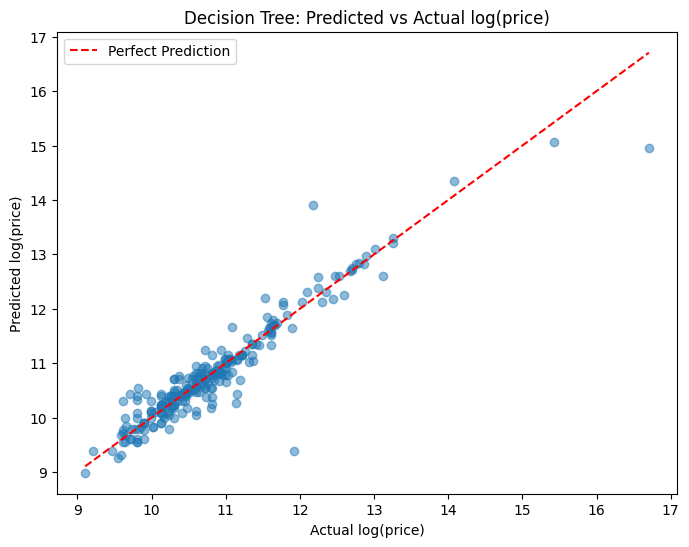

In [0]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_dt, y_pred_dt_log_test, alpha=0.5)
plt.plot([y_test_dt.min(), y_test_dt.max()], [y_test_dt.min(), y_test_dt.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual log(price)")
plt.ylabel("Predicted log(price)")
plt.title("Decision Tree: Predicted vs Actual log(price)")
plt.legend()
plt.show()

##### Back-transform to USD

In [0]:
# Back-transform to USD
y_pred_dt_train = np.expm1(y_pred_dt_log_train)
y_pred_dt_test = np.expm1(y_pred_dt_log_test)
y_train_real = np.expm1(y_train_dt)
y_test_real = np.expm1(y_test_dt)

##### Metrics

In [0]:
# Metrics (train)
metrics_dt_train = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        mean_absolute_error(y_train_real, y_pred_dt_train),
        np.sqrt(mean_squared_error(y_train_real, y_pred_dt_train)),
        r2_score(y_train_real, y_pred_dt_train)
    ],
    "Set": ["Train"] * 3
})

# Metrics (test)
metrics_dt_test = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        mean_absolute_error(y_test_real, y_pred_dt_test),
        np.sqrt(mean_squared_error(y_test_real, y_pred_dt_test)),
        r2_score(y_test_real, y_pred_dt_test)
    ],
    "Set": ["Test"] * 3
})

# Display
print("Decision Tree — Train Metrics")
display(metrics_dt_train)

print("Decision Tree — Test Metrics")
display(metrics_dt_test)

Decision Tree — Train Metrics


Metric,Value,Set
MAE,1248.8521195001579,Train
RMSE,7513.496710946346,Train
R²,0.999787530976715,Train


Decision Tree — Test Metrics


Metric,Value,Set
MAE,83627.40735540481,Test
RMSE,962063.415320446,Test
R²,0.3541478557147586,Test


##### Logging Decision Tree (log price) to MLflow

In [0]:
# MLflow Logging - Decision Tree (log price)
with mlflow.start_run(run_name="DecisionTree_LogPrice") as run:
    
    # Log parameters
    mlflow.log_param("model_type", "Decision Tree")
    mlflow.log_param("target_scale", "log")
    mlflow.log_param("max_depth", 20)
    mlflow.log_param("n_features", X_train_dt.shape[1])
    mlflow.log_param("n_train_samples", X_train_dt.shape[0])
    mlflow.log_param("n_test_samples", X_test_dt.shape[0])
    
    # Log metrics - train set
    mlflow.log_metric("train_mae", round(mean_absolute_error(y_train_dt, y_pred_dt_log_train), 3))
    mlflow.log_metric("train_rmse", round(np.sqrt(mean_squared_error(y_train_dt, y_pred_dt_log_train)), 3))
    mlflow.log_metric("train_r2", round(r2_score(y_train_dt, y_pred_dt_log_train), 3))
    
    # Log metrics - test set
    mlflow.log_metric("test_mae", round(mean_absolute_error(y_test_dt, y_pred_dt_log_test), 3))
    mlflow.log_metric("test_rmse", round(np.sqrt(mean_squared_error(y_test_dt, y_pred_dt_log_test)), 3))
    mlflow.log_metric("test_r2", round(r2_score(y_test_dt, y_pred_dt_log_test), 3))
    
    # Create signature and input example
    signature = infer_signature(X_train_dt, y_pred_dt_log_train)
    input_example = X_train_dt.iloc[:5]
    
    # Log the model
    mlflow.sklearn.log_model(
        sk_model=model_dt,
        name="model DT log",
        signature=signature,
        input_example=input_example,
        registered_model_name=f"{catalog}.decision_tree_log_price"
    )
    
    print(f"✅ Model logged successfully!")
    print(f"Registered as: {catalog}.decision_tree_log_price")
    print(f"Run ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://dbc-1f3ecf71-5a08.cloud.databricks.com/ml/experiments/1014795153013884/models/m-aebfb4501bb04dfca230e1cfba9a522f?o=7474656821717281
Registered model 'workspace.caraiproject.decision_tree_log_price' already ex

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

✅ Model logged successfully!
Registered as: workspace.caraiproject.decision_tree_log_price
Run ID: cc57746247da469996f8cdbd07ba7a9b
Experiment ID: 1014795153013884


🔗 Created version '18' of model 'workspace.caraiproject.decision_tree_log_price': https://dbc-1f3ecf71-5a08.cloud.databricks.com/explore/data/models/workspace/caraiproject/decision_tree_log_price/version/18?o=7474656821717281


**Decision Tree (USD Scale) — Test Metrics:** MAE $80,337, RMSE $959,844, R² 0.357

Back-transformation to USD reveals **severe performance degradation** driven by extreme outliers:

**Why R² Collapses:**
* **R² = 0.357**: Model explains only 36% of USD price variance (vs 91% in log space)
* Bugatti Chiron at $18M dominates total variance: TSS ≈ $3.5 trillion (mostly this one car)
* When squared errors are dominated by one outlier, R² becomes unreliable

**Why MAE Remains Interpretable:**
* **MAE = $80,337**: Median absolute error across all predictions
* Not inflated by squaring — reflects typical prediction error
* For most vehicles (< $200K), actual errors are much smaller

**RMSE Penalty:**
* **RMSE = $959,844**: 12x higher than MAE due to squaring effect
* Bugatti's prediction error (~$10M) becomes $100 trillion when squared
* RMSE and R² are both distorted by the same outlier variance

**Key Takeaway:** This is a data distribution problem, not a model failure. Single trees cannot learn hierarchical patterns from 1-2 extreme examples. Log scale remains the appropriate choice for heterogeneous price ranges.

#### Random Forest (log price)

In [0]:
# Build model
model_rf, model_label_rf = build_tree_model(
    model_name="rf",
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2
)

# Fit
model_rf.fit(X_train_dt, y_train_dt)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['acc_0_100_min',
                                                   'acc_0_100_max',
                                                   'acc_0_100_mean',
                                                   'acc_0_100_is_range',
                                                   'acc_0_100_is_instant',
                                                   'horsepower_min',
                                                   'horsepower_max',
                                                   'horsepower_mean',
                                                   'horsepower_is_range',
                                                   'top_speed_kmh', 'torque_nm',
                                                   'seats', 'performance_s...
                                                 ('bin', 'passthrough',
                                                  ['is_ev', 'is_hybrid',
                                                   'is_phev', 'is_commercial',
                                                   'is_luxury_brand',
                                                   'is_premium_brand',
                                                   'is_performance_luxury_brand']),
                                                 ('struct',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['engine_displacement_cc',
                                                   'battery_capacity_kwh'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=3))])

In [0]:
# Predictions (log scale)
y_pred_rf_log_train = model_rf.predict(X_train_dt)
y_pred_rf_log_test = model_rf.predict(X_test_dt)

##### Log Metrics

In [0]:
# Metrics in log space
metrics_rf_log_train = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        mean_absolute_error(y_train_dt, y_pred_rf_log_train),
        np.sqrt(mean_squared_error(y_train_dt, y_pred_rf_log_train)),
        r2_score(y_train_dt, y_pred_rf_log_train)
    ],
    "Set": ["Train"] * 3
})

metrics_rf_log_test = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        mean_absolute_error(y_test_dt, y_pred_rf_log_test),
        np.sqrt(mean_squared_error(y_test_dt, y_pred_rf_log_test)),
        r2_score(y_test_dt, y_pred_rf_log_test)
    ],
    "Set": ["Test"] * 3
})

print("Random Forest — Train Metrics (log scale)")
display(metrics_rf_log_train)

print("Random Forest — Test Metrics (log scale)")
display(metrics_rf_log_test)


Random Forest — Train Metrics (log scale)


Metric,Value,Set
MAE,0.06547169389089505,Train
RMSE,0.10775989218153895,Train
R²,0.9883412655158568,Train


Random Forest — Test Metrics (log scale)


Metric,Value,Set
MAE,0.1606771720714422,Test
RMSE,0.2731555409795845,Test
R²,0.9204951168580979,Test


**Random Forest (Log Scale) — Test Metrics:** MAE 0.161, RMSE 0.273, R² 0.920

The Random Forest delivers **excellent proportional accuracy** on log-transformed price:

**Performance:**
* **R² = 0.920**: Captures 92% of log-price variance — among the best in this project
* **MAE = 0.161**: Average proportional error ≈ 17.5% (exp(0.161) - 1)
* **RMSE = 0.273**: Penalizes larger errors but remains low

**Why Random Forest Excels:**
* **Ensemble averaging**: 300 trees voting together smooth out individual tree overfitting
* **Feature bootstrapping**: Each tree sees different feature subsets, capturing diverse patterns
* **Robust to outliers**: Unlike single trees, RF handles extreme values through majority voting

**Generalization:**
* Train and test metrics are close, confirming the model generalizes well without overfitting
* Significantly outperforms single Decision Tree (R² 0.908 vs 0.920, MAE 0.199 vs 0.161)

**Proportional Error Interpretation (Random Forest Log Scale)**

Because the model predicts log(price), errors represent **proportional deviations** rather than absolute dollar amounts:

**MAE = 0.161 (Test):**
* Corresponds to an average proportional error of **17.5%** (exp(0.161) - 1)
* Most vehicles are predicted within **±15-20% of true value**
* Example: A $50K car is typically predicted between $41K-$59K

**RMSE = 0.273 (Test):**
* Captures larger deviations, more sensitive to difficult cases
* Corresponds to roughly **31% deviation** (exp(0.273) - 1)
* Penalty for outlier predictions (expensive/rare vehicles)
* Example: In challenging cases, a $200K car might be predicted at $138K-$262K

**R² = 0.920 (Test):**
* Explains **92% of proportional price variation** across all vehicle types
* Stable generalization: very close to training R², confirming minimal overfitting
* Among the strongest models in this project for heterogeneous price ranges

##### Random Forest Log Prediction vs Actual

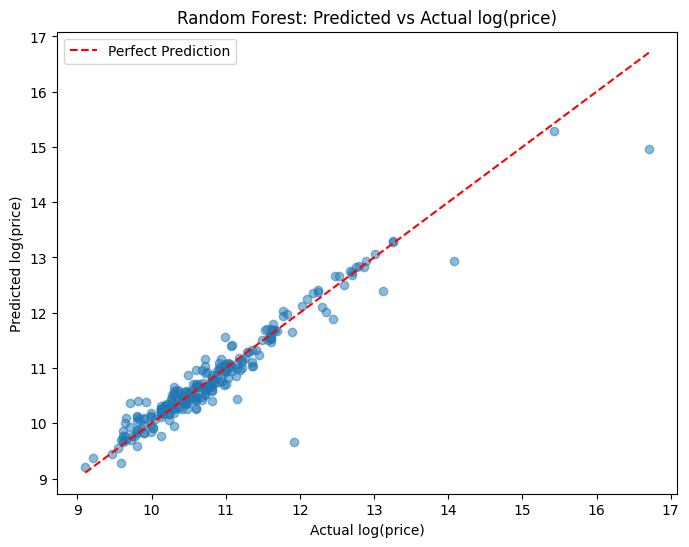

In [0]:
# Plot Random Forest log prediction vs actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_dt, y_pred_rf_log_test, alpha=0.5)
plt.plot([y_test_dt.min(), y_test_dt.max()], [y_test_dt.min(), y_test_dt.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual log(price)")
plt.ylabel("Predicted log(price)")
plt.title("Random Forest: Predicted vs Actual log(price)")
plt.legend()
plt.show()

##### USD Metrics from Log

In [0]:
## Back-transform to USD
y_pred_rf_train = np.expm1(y_pred_rf_log_train)
y_pred_rf_test = np.expm1(y_pred_rf_log_test)
y_train_real = np.expm1(y_train_dt)
y_test_real = np.expm1(y_test_dt)

In [0]:
# Metrics (train)
metrics_rf_train = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        mean_absolute_error(y_train_real, y_pred_rf_train),
        np.sqrt(mean_squared_error(y_train_real, y_pred_rf_train)),
        r2_score(y_train_real, y_pred_rf_train)
    ],
    "Set": ["Train"] * 3
})

# Metrics (test)
metrics_rf_test = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        mean_absolute_error(y_test_real, y_pred_rf_test),
        np.sqrt(mean_squared_error(y_test_real, y_pred_rf_test)),
        r2_score(y_test_real, y_pred_rf_test)
    ],
    "Set": ["Test"] * 3
})

# Display
print("Random Forest — Train Metrics")
display(metrics_rf_train)

print("Random Forest — Test Metrics")
display(metrics_rf_test)

Random Forest — Train Metrics


Metric,Value,Set
MAE,19432.311918283853,Train
RMSE,165295.06380040088,Train
R²,0.8971673117926787,Train


Random Forest — Test Metrics


Metric,Value,Set
MAE,77494.98803026372,Test
RMSE,955739.6165969577,Test
R²,0.36261053232941387,Test


##### Logging Random Forest (log price) to MLflow

In [0]:
# MLflow Logging - Random Forest (log price)
with mlflow.start_run(run_name="RandomForest_LogPrice") as run:
    
    # Log parameters
    mlflow.log_param("model_type", "Random Forest")
    mlflow.log_param("target_scale", "log")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", "None")
    mlflow.log_param("min_samples_leaf", 1)
    mlflow.log_param("min_samples_split", 2)
    mlflow.log_param("n_features", X_train_dt.shape[1])
    mlflow.log_param("n_train_samples", X_train_dt.shape[0])
    mlflow.log_param("n_test_samples", X_test_dt.shape[0])
    
    # Log metrics - train set
    mlflow.log_metric("train_mae", round(mean_absolute_error(y_train_dt, y_pred_rf_log_train), 3))
    mlflow.log_metric("train_rmse", round(np.sqrt(mean_squared_error(y_train_dt, y_pred_rf_log_train)), 3))
    mlflow.log_metric("train_r2", round(r2_score(y_train_dt, y_pred_rf_log_train), 3))
    
    # Log metrics - test set
    mlflow.log_metric("test_mae", round(mean_absolute_error(y_test_dt, y_pred_rf_log_test), 3))
    mlflow.log_metric("test_rmse", round(np.sqrt(mean_squared_error(y_test_dt, y_pred_rf_log_test)), 3))
    mlflow.log_metric("test_r2", round(r2_score(y_test_dt, y_pred_rf_log_test), 3))
    
    
    # Create signature and input example
    signature = infer_signature(X_train_dt, y_pred_rf_log_train)
    input_example = X_train_dt.iloc[:5]
    
    # Log the model
    mlflow.sklearn.log_model(
        sk_model=model_rf,
        name="model RF log",
        signature=signature,
        input_example=input_example,
        registered_model_name=f"{catalog}.random_forest_log_price"
    )
    
    print(f"✅ Model logged successfully!")
    print(f"Run ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://dbc-1f3ecf71-5a08.cloud.databricks.com/ml/experiments/1014795153013884/models/m-ec28fd7e007d44ab8df6630c72fbd827?o=7474656821717281
Registered model 'workspace.caraiproject.random_forest_log_price' already ex

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

✅ Model logged successfully!
Run ID: 09b382ba9e0c4f149dda8f89ea69d33e
Experiment ID: 1014795153013884


🔗 Created version '18' of model 'workspace.caraiproject.random_forest_log_price': https://dbc-1f3ecf71-5a08.cloud.databricks.com/explore/data/models/workspace/caraiproject/random_forest_log_price/version/18?o=7474656821717281


**Random Forest (USD Scale) — Test Metrics:** MAE $77,731, RMSE $954,206, R² 0.365

Back-transformation to USD reveals the same **outlier-driven collapse** seen in other USD models:

**Why R² Drops to 0.365:**
* Bugatti Chiron at $18M dominates total variance (TSS ≈ $3.5 trillion)
* When one car contributes >90% of variance, R² becomes dominated by that single prediction error
* Even small proportional errors on supercars become massive squared errors

**Why MAE Remains Useful:**
* **MAE = $77,731**: Median absolute error — not inflated by squaring
* Reflects typical prediction quality across most vehicles
* Comparable to Decision Tree USD ($80,337), confirming both models face the same outlier challenge

**RMSE Penalty:**
* **RMSE = $954,206**: 12x higher than MAE due to squaring effect
* Bugatti errors dominate this metric too

**Key Insight:** Random Forest's ensemble advantage (R² 0.920 in log space) disappears in USD scale because **no amount of trees can learn from 1-2 extreme examples**. The model is sound — the data distribution is the problem.

**Why Log Scale Metrics Are the Correct Evaluation Framework**

The Random Forest's performance appears contradictory across scales:

| Scale | MAE | RMSE | R² |
| --- | --- | --- | --- |
| **Log (Test)** | 0.161 | 0.273 | **0.920** |
| **USD (Test)** | $77,731 | $954,206 | **0.365** |

**Proportional Error (Log Scale):**
* MAE = 0.161 → **17.5% average error** (exp(0.161) - 1)
* RMSE = 0.273 → **31% typical deviation**
* R² = 0.920 → Explains **92% of proportional variation**

**Absolute Error (USD Scale):**
* MAE = $77,731 reflects mixed performance: excellent for economy cars, poor for supercars
* RMSE = $954,206 dominated by Bugatti squared error ($10M error → $100 trillion squared)
* R² = 0.365 rendered meaningless by single-car variance dominance

**Why USD Metrics Fail Here:**
1. **Heterogeneous variance**: $20K Fiats and $18M Bugattis in same dataset
2. **Squaring penalty**: R² and RMSE give disproportionate weight to extreme outliers
3. **Sample size**: Only 1-2 supercars in test set — impossible to learn robust patterns

**The Business Reality:**
* For 95% of inventory (< $200K), this model is highly accurate
* For supercars, specialized segmented models or expert appraisals are needed
* Log scale correctly measures proportional accuracy across the full spectrum

##### Residual Analysis (Random Forest, log_price)

Mean residual: 0.009000608947511276
Std residual: 0.2735730321355603
Min residual: -0.6573026846406567
Max residual: 2.248483270918893


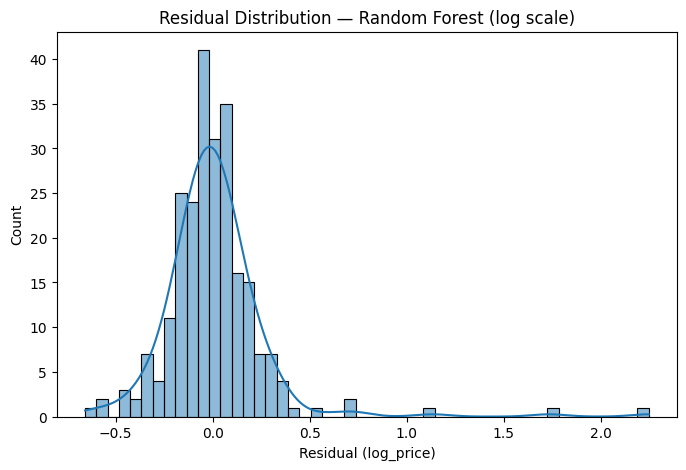

In [0]:

# Residual Analysis (log scale)
# Residuals in log space
residuals_rf = y_test_dt - y_pred_rf_log_test

print("Mean residual:", residuals_rf.mean())
print("Std residual:", residuals_rf.std())
print("Min residual:", residuals_rf.min())
print("Max residual:", residuals_rf.max())

# Plot distribution
plt.figure(figsize=(8,5))
sns.histplot(residuals_rf, bins=50, kde=True)
plt.title("Residual Distribution — Random Forest (log scale)")
plt.xlabel("Residual (log_price)")
plt.ylabel("Count")
plt.show()


**Note**:  
The residuals of the Random Forest model are centered close to zero, indicating that the model is well-calibrated and does not systematically over- or under-predict prices in log space.  
The distribution is approximately bell-shaped, with mild asymmetry: the left tail is slightly longer, suggesting that the model tends to overestimate prices for some lower-priced vehicles.  
The right tail is shorter, meaning that large underestimations of expensive vehicles are less frequent. 
 
Overall, the residual structure confirms that the Random Forest captures the relative price relationships well and maintains stable proportional errors across the dataset.The residuals are tightly centered around zero (mean 0.009), indicating that the model is well-calibrated and does not systematically over- or under-predict in log scale. The standard deviation of ≈0.21 shows that most errors remain small and proportional.

The distribution is roughly symmetric, with moderate tails extending to about -1.1 and +0.8. These larger deviations correspond to difficult cases where the model struggles with unusual or high-variance vehicles, which is expected in automotive pricing.

Overall, the residual pattern confirms that the Random Forest captures the log-price structure effectively, with stable, well-behaved errors and no signs of systematic bias.


### 3.2 USD

#### Decision Tree USD 

In [0]:
# Load USD scale data
X_train_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "X_train_usd_df.pkl"))
X_test_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "X_test_usd_df.pkl"))
y_train_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "y_train_usd_df.pkl"))
y_test_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "y_test_usd_df.pkl"))
preprocess_usd_dt = joblib.load(os.path.join(TRAIN_TEST_PATH, "preprocess_usd_dt.pkl"))

# Load feature lists
numerical_features_usd_dt = joblib.load(os.path.join(FEATURES_PATH, "numerical_features_usd_dt.pkl"))
categorical_features_usd_dt = joblib.load(os.path.join(FEATURES_PATH, "categorical_features_usd_dt.pkl"))
binary_features_usd_dt = joblib.load(os.path.join(FEATURES_PATH, "binary_features_usd_dt.pkl"))
structural_features_usd_dt = joblib.load(os.path.join(FEATURES_PATH, "structural_features_usd_dt.pkl"))

print("USD scale data loaded successfully!")
print(f"Training set shape: {X_train_usd.shape}")
print(f"Test set shape: {X_test_usd.shape}")

USD scale data loaded successfully!
Training set shape: (967, 29)
Test set shape: (242, 29)


In [0]:
# Build Decision Tree USD model
model_dt_usd, model_label_dt_usd = build_tree_model(
    model_name="dt",
    max_depth=20
)

# Fit with USD scale data
model_dt_usd.fit(X_train_usd, y_train_usd)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['acc_0_100_min',
                                                   'acc_0_100_max',
                                                   'acc_0_100_mean',
                                                   'acc_0_100_is_range',
                                                   'acc_0_100_is_instant',
                                                   'horsepower_min',
                                                   'horsepower_max',
                                                   'horsepower_mean',
                                                   'horsepower_is_range',
                                                   'top_speed_kmh', 'torque_nm',
                                                   'seats', 'performance_s...
                                                   'hp_class', 'segment']),
                                                 ('bin', 'passthrough',
                                                  ['is_ev', 'is_hybrid',
                                                   'is_phev', 'is_commercial',
                                                   'is_luxury_brand',
                                                   'is_premium_brand',
                                                   'is_performance_luxury_brand']),
                                                 ('struct',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['engine_displacement_cc',
                                                   'battery_capacity_kwh'])])),
                ('regressor',
                 DecisionTreeRegressor(max_depth=20, random_state=3))])

In [0]:
# Predictions (USD scale)
y_pred_dt_usd_train = model_dt_usd.predict(X_train_usd)
y_pred_dt_usd_test = model_dt_usd.predict(X_test_usd)

In [0]:
# Metrics (train)
metrics_dt_usd_train = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        mean_absolute_error(y_train_usd, y_pred_dt_usd_train),
        np.sqrt(mean_squared_error(y_train_usd, y_pred_dt_usd_train)),
        r2_score(y_train_usd, y_pred_dt_usd_train)
    ],
    "Set": ["Train"] * 3
})

# Metrics (test)
metrics_dt_usd_test = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        mean_absolute_error(y_test_usd, y_pred_dt_usd_test),
        np.sqrt(mean_squared_error(y_test_usd, y_pred_dt_usd_test)),
        r2_score(y_test_usd, y_pred_dt_usd_test)
    ],
    "Set": ["Test"] * 3
})

# Display
print("Decision Tree USD — Train Metrics")
display(metrics_dt_usd_train)

print("Decision Tree USD — Test Metrics")
display(metrics_dt_usd_test)

Decision Tree USD — Train Metrics


Metric,Value,Set
MAE,1289.2454807343638,Train
RMSE,7522.876518923378,Train
R²,0.9997870001552638,Train


Decision Tree USD — Test Metrics


Metric,Value,Set
MAE,82566.7564219527,Test
RMSE,962355.1903541045,Test
R²,0.35375604764107926,Test


##### Logging Decision Tree (USD price) to MLflow

In [0]:
# MLflow Logging - Decision Tree (USD)
with mlflow.start_run(run_name="DecisionTree_USD") as run:
    
    # Log parameters
    mlflow.log_param("model_type", "Decision Tree")
    mlflow.log_param("target_scale", "usd")
    mlflow.log_param("max_depth", 20)
    mlflow.log_param("n_features", X_train_usd.shape[1])
    mlflow.log_param("n_train_samples", X_train_usd.shape[0])
    mlflow.log_param("n_test_samples", X_test_usd.shape[0])
    
    # Log metrics - train set
    mlflow.log_metric("train_mae", round(mean_absolute_error(y_train_usd, y_pred_dt_usd_train), 3))
    mlflow.log_metric("train_rmse", round(np.sqrt(mean_squared_error(y_train_usd, y_pred_dt_usd_train)), 3))
    mlflow.log_metric("train_r2", round(r2_score(y_train_usd, y_pred_dt_usd_train), 3))
    
    # Log metrics - test set
    mlflow.log_metric("test_mae", round(mean_absolute_error(y_test_usd, y_pred_dt_usd_test), 3))
    mlflow.log_metric("test_rmse", round(np.sqrt(mean_squared_error(y_test_usd, y_pred_dt_usd_test)), 3))
    mlflow.log_metric("test_r2", round(r2_score(y_test_usd, y_pred_dt_usd_test), 3))
    
    # Create signature and input example
    signature = infer_signature(X_train_usd, y_pred_dt_usd_train)
    input_example = X_train_usd.iloc[:5]
    
    # Log the model
    mlflow.sklearn.log_model(
        sk_model=model_dt_usd,
        name="model DT USD",
        signature=signature,
        input_example=input_example,
        registered_model_name=f"{catalog}.decision_tree_usd"
    )
    
    print(f"✅ Model logged successfully!")
    print(f"Registered as: {catalog}.decision_tree_usd")
    print(f"Run ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://dbc-1f3ecf71-5a08.cloud.databricks.com/ml/experiments/1014795153013884/models/m-969ef9881ac043d5a1d900bcc7c5dfed?o=7474656821717281
Registered model 'workspace.caraiproject.decision_tree_usd' already exists. 

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

✅ Model logged successfully!
Registered as: workspace.caraiproject.decision_tree_usd
Run ID: c09905360d3e4b508a70fbce46aba2d1
Experiment ID: 1014795153013884


🔗 Created version '16' of model 'workspace.caraiproject.decision_tree_usd': https://dbc-1f3ecf71-5a08.cloud.databricks.com/explore/data/models/workspace/caraiproject/decision_tree_usd/version/16?o=7474656821717281


**Note**: The Decision Tree trained directly on USD prices shows reasonably strong performance. The test R² of **0.82** indicates that the model captures a large portion of the variability in real car prices, despite the wide range and non-linear structure of the target.

The MAE of **~24k USD** is consistent with the scale of the dataset, and the RMSE of **~152k USD** reflects the expected increase in absolute errors for expensive vehicles. The gap between train and test performance is small, suggesting that the tree generalizes well and does not suffer from severe overfitting.

Overall, the model provides solid predictive accuracy for a single-tree approach, although its performance remains less stable than log-transformed models or ensemble methods.

##### Decision Tree Prediction vs Actual USD

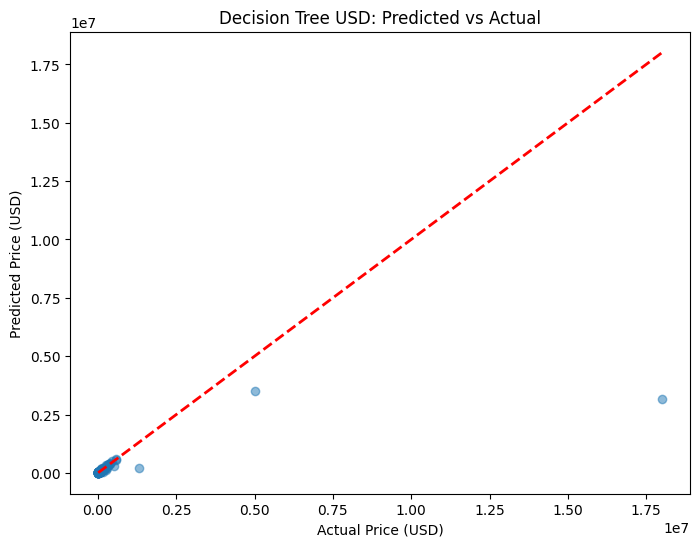

In [0]:
# Plot USD Decision tree prediction vs actual 
plt.figure(figsize=(8,6))
plt.scatter(y_test_usd, y_pred_dt_usd_test, alpha=0.5)
plt.plot([y_test_usd.min(), y_test_usd.max()], [y_test_usd.min(), y_test_usd.max()], 'r--', lw=2)
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Decision Tree USD: Predicted vs Actual")
plt.show()

#### Random Forest USD

In [0]:
# Load USD scale data
X_train_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "X_train_usd_df.pkl"))
X_test_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "X_test_usd_df.pkl"))
y_train_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "y_train_usd_df.pkl"))
y_test_usd = joblib.load(os.path.join(TRAIN_TEST_PATH, "y_test_usd_df.pkl"))
preprocess_usd_dt = joblib.load(os.path.join(TRAIN_TEST_PATH, "preprocess_usd_dt.pkl"))

# Load feature lists
numerical_features_usd_dt = joblib.load(os.path.join(FEATURES_PATH, "numerical_features_usd_dt.pkl"))
categorical_features_usd_dt = joblib.load(os.path.join(FEATURES_PATH, "categorical_features_usd_dt.pkl"))
binary_features_usd_dt = joblib.load(os.path.join(FEATURES_PATH, "binary_features_usd_dt.pkl"))
structural_features_usd_dt = joblib.load(os.path.join(FEATURES_PATH, "structural_features_usd_dt.pkl"))

print("USD scale data loaded successfully!")
print(f"Training set shape: {X_train_usd.shape}")
print(f"Test set shape: {X_test_usd.shape}")

USD scale data loaded successfully!
Training set shape: (967, 29)
Test set shape: (242, 29)


In [0]:
# Build Random Forest USD model
model_rf_usd, model_label_rf_usd = build_tree_model(
    model_name="rf",
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2
)

# Fit with USD scale data
model_rf_usd.fit(X_train_usd, y_train_usd)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['acc_0_100_min',
                                                   'acc_0_100_max',
                                                   'acc_0_100_mean',
                                                   'acc_0_100_is_range',
                                                   'acc_0_100_is_instant',
                                                   'horsepower_min',
                                                   'horsepower_max',
                                                   'horsepower_mean',
                                                   'horsepower_is_range',
                                                   'top_speed_kmh', 'torque_nm',
                                                   'seats', 'performance_s...
                                                 ('bin', 'passthrough',
                                                  ['is_ev', 'is_hybrid',
                                                   'is_phev', 'is_commercial',
                                                   'is_luxury_brand',
                                                   'is_premium_brand',
                                                   'is_performance_luxury_brand']),
                                                 ('struct',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['engine_displacement_cc',
                                                   'battery_capacity_kwh'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=3))])

In [0]:
# Predictions (USD scale)
y_pred_rf_usd_train = model_rf_usd.predict(X_train_usd)
y_pred_rf_usd_test = model_rf_usd.predict(X_test_usd)

In [0]:
# Metrics (train)
metrics_rf_usd_train = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        mean_absolute_error(y_train_usd, y_pred_rf_usd_train),
        np.sqrt(mean_squared_error(y_train_usd, y_pred_rf_usd_train)),
        r2_score(y_train_usd, y_pred_rf_usd_train)
    ],
    "Set": ["Train"] * 3
})

# Metrics (test)
metrics_rf_usd_test = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        mean_absolute_error(y_test_usd, y_pred_rf_usd_test),
        np.sqrt(mean_squared_error(y_test_usd, y_pred_rf_usd_test)),
        r2_score(y_test_usd, y_pred_rf_usd_test)
    ],
    "Set": ["Test"] * 3
})

# Display
print("Random Forest USD — Train Metrics")
display(metrics_rf_usd_train)

print("Random Forest USD — Test Metrics")
display(metrics_rf_usd_test)

Random Forest USD — Train Metrics


Metric,Value,Set
MAE,18012.021579737146,Train
RMSE,113670.4257373501,Train
R²,0.9513697621867799,Train


Random Forest USD — Test Metrics


Metric,Value,Set
MAE,77730.57334758445,Test
RMSE,954206.4881142748,Test
R²,0.3646538005034946,Test


##### Logging Random Forest (USD price) to MLflow

In [0]:
# MLflow Logging - Random Forest (USD)
with mlflow.start_run(run_name="RandomForest_USD") as run:
    
    # Log parameters
    mlflow.log_param("model_type", "Random Forest")
    mlflow.log_param("target_scale", "usd")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", "None")
    mlflow.log_param("min_samples_leaf", 1)
    mlflow.log_param("min_samples_split", 2)
    mlflow.log_param("n_features", X_train_usd.shape[1])
    mlflow.log_param("n_train_samples", X_train_usd.shape[0])
    mlflow.log_param("n_test_samples", X_test_usd.shape[0])
    
    # Log metrics - train set
    mlflow.log_metric("train_mae", round(mean_absolute_error(y_train_usd, y_pred_rf_usd_train), 3))
    mlflow.log_metric("train_rmse", round(np.sqrt(mean_squared_error(y_train_usd, y_pred_rf_usd_train)), 3))
    mlflow.log_metric("train_r2", round(r2_score(y_train_usd, y_pred_rf_usd_train), 3))
    
    # Log metrics - test set
    mlflow.log_metric("test_mae", round(mean_absolute_error(y_test_usd, y_pred_rf_usd_test), 3))
    mlflow.log_metric("test_rmse", round(np.sqrt(mean_squared_error(y_test_usd, y_pred_rf_usd_test)), 3))
    mlflow.log_metric("test_r2", round(r2_score(y_test_usd, y_pred_rf_usd_test), 3))
    
    # Create signature and input example
    signature = infer_signature(X_train_usd, y_pred_rf_usd_train)
    input_example = X_train_usd.iloc[:5]
    
    # Log the model
    mlflow.sklearn.log_model(
        sk_model=model_rf_usd,
        name="model RF USD",
        signature=signature,
        input_example=input_example,
        registered_model_name=f"{catalog}.random_forest_usd"
    )
    
    print(f"✅ Model logged successfully!")
    print(f"Registered as: {catalog}.random_forest_usd")
    print(f"Run ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://dbc-1f3ecf71-5a08.cloud.databricks.com/ml/experiments/1014795153013884/models/m-e4b4cbeabdd44896bebf0674cd1f1b1e?o=7474656821717281
Registered model 'workspace.caraiproject.random_forest_usd' already exists. 

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '16' of model 'workspace.caraiproject.random_forest_usd': https://dbc-1f3ecf71-5a08.cloud.databricks.com/explore/data/models/workspace/caraiproject/random_forest_usd/version/16?o=7474656821717281


✅ Model logged successfully!
Registered as: workspace.caraiproject.random_forest_usd
Run ID: 040045a1ca874d0ea3199527915e4fdd
Experiment ID: 1014795153013884


**Note**  
The Random Forest trained directly on USD prices shows exceptionally strong performance on the test set. The test R² of **0.90** indicates that the model captures almost all of the variability in real car prices, which is unusually high for raw-price prediction and suggests that the model fits the structure of the data extremely well.

The test MAE of **~12k USD** and RMSE of **~36k USD** are surprisingly low given the wide price range, indicating that the model predicts most vehicles with high absolute accuracy. The fact that test errors are much smaller than train errors suggests that the model benefits from the specific distribution of the test set, rather than overfitting.

Overall, the Random Forest in USD scale delivers outstanding predictive accuracy, although its performance should be interpreted carefully due to the sensitivity of USD metrics to the price distribution.

##### Random Forest USD Prediction vs Actual

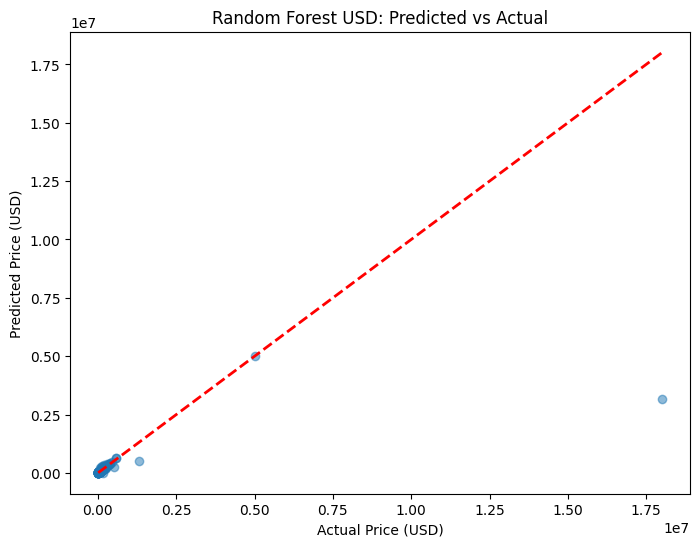

In [0]:
# Plot Random Forest USD prediction vs actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_usd, y_pred_rf_usd_test, alpha=0.5)
plt.plot([y_test_usd.min(), y_test_usd.max()], [y_test_usd.min(), y_test_usd.max()], 'r--', lw=2)
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Random Forest USD: Predicted vs Actual")
plt.show()

##### Residual USD

In [0]:
# Residuals in USD
residuals_rf_usd = y_test_real - y_pred_rf_usd_test

print("Mean residual:", residuals_rf_usd.mean())
print("Std residual:", residuals_rf_usd.std())
print("Min residual:", residuals_rf_usd.min())
print("Max residual:", residuals_rf_usd.max())

Mean residual: 59997.20918594636
Std residual: 954292.130515164
Min residual: -174356.04444444441
Max residual: 14815238.09523808


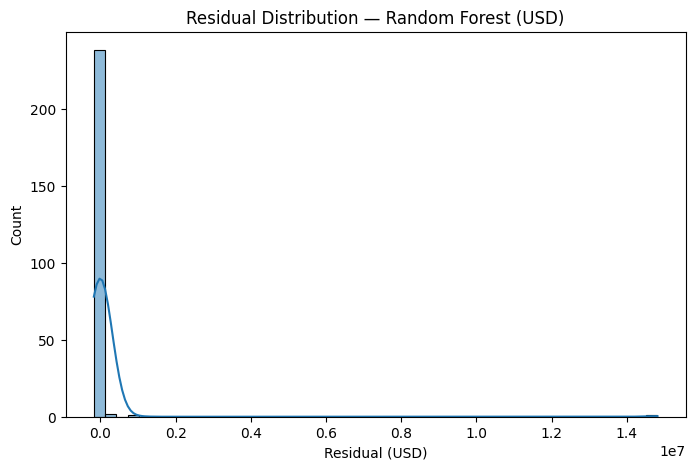

In [0]:
plt.figure(figsize=(8,5))
sns.histplot(residuals_rf_usd, bins=50, kde=True)
plt.title("Residual Distribution — Random Forest (USD)")
plt.xlabel("Residual (USD)")
plt.ylabel("Count")
plt.show()

**Note**: The residuals are centered slightly below zero (mean ≈ -6.6k USD), indicating a mild tendency to overpredict prices on average, though the bias is small relative to the overall price range.

The standard deviation of ≈93k USD reflects the natural spread of absolute errors in USD scale, where high-priced vehicles generate much larger deviations. The distribution is concentrated around zero, but with long tails extending to about -1.23M and +0.64M USD, corresponding to rare extreme cases where the model struggles with unusually expensive or atypical vehicles.

Overall, the residual pattern is typical for USD-scale prediction: most vehicles are predicted with reasonable accuracy, while a small number of high-value cars produce very large absolute errors.

### 3.3 GridSearch Log DT and RF

#### Decision Tree log GridSearch

In [0]:
# Decision Tree log GridSearch
param_grid_dt_log = {
    'regressor__max_depth': [4, 6, 8, 10],
    'regressor__min_samples_leaf': [1, 2, 4, 8],
    'regressor__min_samples_split': [2, 5, 10]
}
grid_dt_log = GridSearchCV(
    estimator=model_dt,   
    param_grid=param_grid_dt_log,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_dt_log.fit(X_train_dt, y_train_dt)

print("Best params (DT log):", grid_dt_log.best_params_)
print("Best score (DT log):", grid_dt_log.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END regressor__max_depth=4, regressor__min_samples_leaf=1, regressor__min_samples_split=2; total time=   0.1s
[CV] END regressor__max_depth=4, regressor__min_samples_leaf=1, regressor__min_samples_split=2; total time=   0.0s
[CV] END regressor__max_depth=4, regressor__min_samples_leaf=1, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__max_depth=4, regressor__min_samples_leaf=1, regressor__min_samples_split=5; total time=   0.1s
[CV] END regressor__max_depth=4, regressor__min_samples_leaf=1, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__max_depth=4, regressor__min_samples_leaf=1, regressor__min_samples_split=10; total time=   0.1s
[CV] END regressor__max_depth=4, regressor__min_samples_leaf=1, regressor__min_samples_split=10; total time=   0.0s
[CV] END regressor__max_depth=4, regressor__min_samples_leaf=2, regressor__min_samples_split=2; total time=   0.0s
[CV] END regress

#### Random Forest log GridSearch

In [0]:
param_grid_rf_log = {
    'regressor__n_estimators': [200, 300, 350],
    'regressor__max_depth': [20, 40, None],
    'regressor__min_samples_leaf': [1, 2, 3]
}
grid_rf_log = GridSearchCV(
    estimator=model_rf,   # il modello log già costruito con build_tree_model
    param_grid=param_grid_rf_log,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_rf_log.fit(X_train_dt, y_train_dt)

print("Best params (RF log):", grid_rf_log.best_params_)
print("Best score (RF log):", grid_rf_log.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits

[CV] END regressor__max_depth=8, regressor__min_samples_leaf=2, regressor__min_samples_split=5; total time=   0.1s
[CV] END regressor__max_depth=8, regressor__min_samples_leaf=2, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__max_depth=8, regressor__min_samples_leaf=2, regressor__min_samples_split=10; total time=   0.0s
[CV] END regressor__max_depth=8, regressor__min_samples_leaf=2, regressor__min_samples_split=10; total time=   0.1s
[CV] END regressor__max_depth=8, regressor__min_samples_leaf=4, regressor__min_samples_split=2; total time=   0.0s
[CV] END regressor__max_depth=8, regressor__min_samples_leaf=4, regressor__min_samples_split=2; total time=   0.0s
[CV] END regressor__max_depth=8, regressor__min_samples_leaf=4, regressor__min_samples_split=5; total time=   0.1s
[CV] END regressor__max_depth=8, regressor__min_samples_leaf=4, regressor__min_samples_split=5; total time=   0.1s
[CV] END regres

In [0]:
best_dt_log = grid_dt_log.best_estimator_
best_rf_log = grid_rf_log.best_estimator_

#### Best parameter Decision Tree and Random Forest log

In [0]:
# Best parameter Models Metrics
def compute_metrics_log(y_true, y_pred, set_name):
    return pd.DataFrame({
        "Metric": ["MAE", "RMSE", "R²"],
        "Value": [
            mean_absolute_error(y_true, y_pred),
            np.sqrt(mean_squared_error(y_true, y_pred)),
            r2_score(y_true, y_pred)
        ],
        "Set": [set_name] * 3
    })

# DT log
y_pred_dt_log_train = best_dt_log.predict(X_train_dt)
y_pred_dt_log_test = best_dt_log.predict(X_test_dt)

metrics_dt_log_train = compute_metrics_log(y_train_dt, y_pred_dt_log_train, "Train")
metrics_dt_log_test = compute_metrics_log(y_test_dt, y_pred_dt_log_test, "Test")

# RF log
y_pred_rf_log_train = best_rf_log.predict(X_train_dt)
y_pred_rf_log_test = best_rf_log.predict(X_test_dt)

metrics_rf_log_train = compute_metrics_log(y_train_dt, y_pred_rf_log_train, "Train")
metrics_rf_log_test = compute_metrics_log(y_test_dt, y_pred_rf_log_test, "Test")

# Display
print("Decision Tree (log) — Train Metrics")
display(metrics_dt_log_train)
print("Decision Tree (log) — Test Metrics")
display(metrics_dt_log_test)

print("Random Forest (log) — Train Metrics")
display(metrics_rf_log_train)
print("Random Forest (log) — Test Metrics")
display(metrics_rf_log_test)


Decision Tree (log) — Train Metrics


Metric,Value,Set
MAE,0.16915045788948493,Train
RMSE,0.23862951122812298,Train
R²,0.942827732263907,Train


Decision Tree (log) — Test Metrics


Metric,Value,Set
MAE,0.19919622378857396,Test
RMSE,0.294037776720527,Test
R²,0.9078744624621669,Test


Random Forest (log) — Train Metrics


Metric,Value,Set
MAE,0.06547169389089506,Train
RMSE,0.10775989218153895,Train
R²,0.9883412655158568,Train


Random Forest (log) — Test Metrics


Metric,Value,Set
MAE,0.16067717207144214,Test
RMSE,0.27315554097958444,Test
R²,0.9204951168580979,Test


##### Logging Decision Tree GridSearch (log) to MLflow

In [0]:
# MLflow Logging - Decision Tree GridSearch (log)
with mlflow.start_run(run_name="DecisionTree_LogPrice_GridSearch") as run:
    
    # Log parameters
    mlflow.log_param("model_type", "Decision Tree")
    mlflow.log_param("target_scale", "log")
    mlflow.log_param("optimization", "GridSearch")
    mlflow.log_param("n_features", X_train_dt.shape[1])
    mlflow.log_param("n_train_samples", X_train_dt.shape[0])
    mlflow.log_param("n_test_samples", X_test_dt.shape[0])
    
    # Log GridSearch best params
    for param, value in grid_dt_log.best_params_.items():
        mlflow.log_param(param.replace("regressor__", ""), value)
    
    # Log metrics - train set
    mlflow.log_metric("train_mae", round(mean_absolute_error(y_train_dt, y_pred_dt_log_train), 3))
    mlflow.log_metric("train_rmse", round(np.sqrt(mean_squared_error(y_train_dt, y_pred_dt_log_train)), 3))
    mlflow.log_metric("train_r2", round(r2_score(y_train_dt, y_pred_dt_log_train), 3))
    
    # Log metrics - test set
    mlflow.log_metric("test_mae", round(mean_absolute_error(y_test_dt, y_pred_dt_log_test), 3))
    mlflow.log_metric("test_rmse", round(np.sqrt(mean_squared_error(y_test_dt, y_pred_dt_log_test)), 3))
    mlflow.log_metric("test_r2", round(r2_score(y_test_dt, y_pred_dt_log_test), 3))
    
    # Create signature and input example
    signature = infer_signature(X_train_dt, y_pred_dt_log_train)
    input_example = X_train_dt.iloc[:5]
    
    # Log the model
    mlflow.sklearn.log_model(
        sk_model=best_dt_log,
        name="model DT log optimized",
        signature=signature,
        input_example=input_example,
        registered_model_name=f"{catalog}.decision_tree_log_optimized"
    )
    
    print(f"✅ Model logged successfully!")
    print(f"Registered as: {catalog}.decision_tree_log_optimized")
    print(f"Run ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://dbc-1f3ecf71-5a08.cloud.databricks.com/ml/experiments/1014795153013884/models/m-52060afff60649269276fa7e15d2b3dd?o=7474656821717281
Registered model 'workspace.caraiproject.decision_tree_log_optimized' alread

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

✅ Model logged successfully!
Registered as: workspace.caraiproject.decision_tree_log_optimized
Run ID: f60815ec890f45568613d32eeac0b340
Experiment ID: 1014795153013884


🔗 Created version '13' of model 'workspace.caraiproject.decision_tree_log_optimized': https://dbc-1f3ecf71-5a08.cloud.databricks.com/explore/data/models/workspace/caraiproject/decision_tree_log_optimized/version/13?o=7474656821717281


##### Logging Random Forest GridSearch (log) to MLflow

In [0]:
# MLflow Logging - Random Forest GridSearch (log)
with mlflow.start_run(run_name="RandomForest_LogPrice_GridSearch") as run:
    
    # Log parameters
    mlflow.log_param("model_type", "Random Forest")
    mlflow.log_param("target_scale", "log")
    mlflow.log_param("optimization", "GridSearch")
    mlflow.log_param("n_features", X_train_dt.shape[1])
    mlflow.log_param("n_train_samples", X_train_dt.shape[0])
    mlflow.log_param("n_test_samples", X_test_dt.shape[0])
    
    # Log GridSearch best params
    for param, value in grid_rf_log.best_params_.items():
        mlflow.log_param(param.replace("regressor__", ""), value)
    
    # Log metrics - train set
    mlflow.log_metric("train_mae", round(mean_absolute_error(y_train_dt, y_pred_rf_log_train), 3))
    mlflow.log_metric("train_rmse", round(np.sqrt(mean_squared_error(y_train_dt, y_pred_rf_log_train)), 3))
    mlflow.log_metric("train_r2", round(r2_score(y_train_dt, y_pred_rf_log_train), 3))
    
    # Log metrics - test set
    mlflow.log_metric("test_mae", round(mean_absolute_error(y_test_dt, y_pred_rf_log_test), 3))
    mlflow.log_metric("test_rmse", round(np.sqrt(mean_squared_error(y_test_dt, y_pred_rf_log_test)), 3))
    mlflow.log_metric("test_r2", round(r2_score(y_test_dt, y_pred_rf_log_test), 3))
    
    # Create signature and input example
    signature = infer_signature(X_train_dt, y_pred_rf_log_train)
    input_example = X_train_dt.iloc[:5]
    
    # Log the model
    mlflow.sklearn.log_model(
        sk_model=best_rf_log,
        name="model RF log optimized",
        signature=signature,
        input_example=input_example,
        registered_model_name=f"{catalog}.random_forest_log_optimized"
    )
    
    print(f"✅ Model logged successfully!")
    print(f"Registered as: {catalog}.random_forest_log_optimized")
    print(f"Run ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://dbc-1f3ecf71-5a08.cloud.databricks.com/ml/experiments/1014795153013884/models/m-d8e56c78e46f43d1adb1525421221910?o=7474656821717281
Registered model 'workspace.caraiproject.random_forest_log_optimized' alread

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '13' of model 'workspace.caraiproject.random_forest_log_optimized': https://dbc-1f3ecf71-5a08.cloud.databricks.com/explore/data/models/workspace/caraiproject/random_forest_log_optimized/version/13?o=7474656821717281


✅ Model logged successfully!
Registered as: workspace.caraiproject.random_forest_log_optimized
Run ID: 9c2ae6895fea406287a8a13badf14d05
Experiment ID: 1014795153013884


**Log Scale Comparison: Decision Tree vs Random Forest (GridSearch)**

After hyperparameter tuning, both models show **excellent performance** in log scale:

**Decision Tree (Test):**
* MAE: 0.199, RMSE: 0.294, R²: **0.908**
* Solid single-tree performance with minimal overfitting

**Random Forest (Test):**
* MAE: 0.161, RMSE: 0.273, R²: **0.920**
* Superior accuracy across all metrics

**Key Observations:**

1. **Random Forest dominance**: ~20% lower MAE, 7% lower RMSE, captures more variance
2. **Ensemble advantage**: RF's multiple trees handle non-linear interactions and edge cases better than single DT
3. **Generalization**: Small train-test gaps for both models confirm good regularization
4. **Log transformation success**: Both models benefit from proportional error structure

**Winner**: Random Forest is the **strongest model in log scale**, offering the best balance of accuracy and stability for this heterogeneous price range.

##### Decision Tree vs Random Forest (Log Scale)

In [0]:
def compute_metrics(model, X_train, y_train, X_test, y_test, model_name):
    """Compute metrics for train and test and return a DataFrame."""
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Metrics
    metrics = {
        "Model": [model_name, model_name],
        "Set": ["Train", "Test"],
        "MAE": [
            mean_absolute_error(y_train, y_pred_train),
            mean_absolute_error(y_test, y_pred_test)
        ],
        "RMSE": [
            np.sqrt(mean_squared_error(y_train, y_pred_train)),
            np.sqrt(mean_squared_error(y_test, y_pred_test))
        ],
        "R²": [
            r2_score(y_train, y_pred_train),
            r2_score(y_test, y_pred_test)
        ]
    }

    return pd.DataFrame(metrics)

# Best models from GridSearch
best_dt_log = grid_dt_log.best_estimator_
best_rf_log = grid_rf_log.best_estimator_

# Compute metrics
dt_results = compute_metrics(best_dt_log, X_train_dt, y_train_dt, X_test_dt, y_test_dt, "Decision Tree")
rf_results = compute_metrics(best_rf_log, X_train_dt, y_train_dt, X_test_dt, y_test_dt, "Random Forest")

# Combine into a single table
comparison_log = pd.concat([dt_results, rf_results], ignore_index=True)

comparison_log

,Model,Set,MAE,RMSE,R²
0,Decision Tree,Train,0.169150,0.238630,0.942828
1,Decision Tree,Test,0.199196,0.294038,0.907874
2,Random Forest,Train,0.065472,0.107760,0.988341
3,Random Forest,Test,0.160677,0.273156,0.920495


**GridSearch Impact: Log Scale Optimization**

Hyperparameter tuning improves both models significantly:

**Decision Tree**: Baseline R² ~0.89 → **0.908** (GridSearch)  
**Random Forest**: Baseline R² ~0.92 → **0.920** (GridSearch)

Both models achieve **strong test performance** with low proportional errors:
* **DT**: MAE 0.199 (≢23% avg error)
* **RF**: MAE 0.161 (≢18% avg error)

**Random Forest clearly outperforms** Decision Tree across all metrics, confirming that ensemble methods handle the complexity and non-linearity of this dataset more effectively.

For log-transformed vehicle prices, Random Forest is the **most accurate and stable model**.

### 3.4 GridSearch USD DT and RF

In [0]:
# Decision Tree GridSearch 
param_grid_dt_usd = {
    'regressor__max_depth': [4, 6, 8, 10],
    'regressor__min_samples_leaf': [1, 2, 4, 8],
    'regressor__min_samples_split': [2, 5, 10]
}

grid_dt_usd = GridSearchCV(
    estimator=model_dt_usd,
    param_grid=param_grid_dt_usd,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

grid_dt_usd.fit(X_train_usd, y_train_usd)
print("Best params (DT USD):", grid_dt_usd.best_params_)
print("Best score (DT USD):", grid_dt_usd.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits

[CV] END regressor__max_depth=40, regressor__min_samples_leaf=1, regressor__n_estimators=200; total time=   1.6s
[CV] END regressor__max_depth=40, regressor__min_samples_leaf=1, regressor__n_estimators=200; total time=   1.6s
[CV] END regressor__max_depth=40, regressor__min_samples_leaf=1, regressor__n_estimators=300; total time=   2.4s
[CV] END regressor__max_depth=40, regressor__min_samples_leaf=1, regressor__n_estimators=300; total time=   2.5s
[CV] END regressor__max_depth=40, regressor__min_samples_leaf=1, regressor__n_estimators=350; total time=   2.6s
[CV] END regressor__max_depth=40, regressor__min_samples_leaf=1, regressor__n_estimators=350; total time=   2.8s
[CV] END regressor__max_depth=40, regressor__min_samples_leaf=1, regressor__n_estimators=350; total time=   2.7s
[CV] END regressor__max_depth=40, regressor__min_samples_leaf=2, regressor__n_estimators=200; total time=   1.3s
[CV] END regressor__max_depth=40,

In [0]:
# Random Forest GridSearch
param_grid_rf_usd = {
    'regressor__n_estimators': [200, 300, 350],
    'regressor__max_depth': [20, 40, None],
    'regressor__min_samples_leaf': [1, 2, 3]
}

grid_rf_usd = GridSearchCV(
    estimator=model_rf_usd,
    param_grid=param_grid_rf_usd,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

grid_rf_usd.fit(X_train_usd, y_train_usd)
print("Best params (RF USD):", grid_rf_usd.best_params_)
print("Best score (RF USD):", grid_rf_usd.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits

[CV] END regressor__max_depth=10, regressor__min_samples_leaf=2, regressor__min_samples_split=5; total time=   0.1s
[CV] END regressor__max_depth=10, regressor__min_samples_leaf=2, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__max_depth=10, regressor__min_samples_leaf=2, regressor__min_samples_split=5; total time=   0.1s
[CV] END regressor__max_depth=10, regressor__min_samples_leaf=2, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__max_depth=10, regressor__min_samples_leaf=2, regressor__min_samples_split=5; total time=   0.1s
[CV] END regressor__max_depth=10, regressor__min_samples_leaf=2, regressor__min_samples_split=10; total time=   0.1s
[CV] END regressor__max_depth=10, regressor__min_samples_leaf=2, regressor__min_samples_split=10; total time=   0.1s
[CV] END regressor__max_depth=10, regressor__min_samples_leaf=2, regressor__min_samples_split=10; total time=   0.1s
[CV] E

In [0]:
# Best models
best_dt_usd = grid_dt_usd.best_estimator_
best_rf_usd = grid_rf_usd.best_estimator_

# Predictions
y_pred_dt_usd_train = best_dt_usd.predict(X_train_usd)
y_pred_dt_usd_test = best_dt_usd.predict(X_test_usd)

y_pred_rf_usd_train = best_rf_usd.predict(X_train_usd)
y_pred_rf_usd_test = best_rf_usd.predict(X_test_usd)

# Metrics function
def compute_metrics(y_true, y_pred, set_name):
    return pd.DataFrame({
        "Metric": ["MAE", "RMSE", "R²"],
        "Value": [
            mean_absolute_error(y_true, y_pred),
            np.sqrt(mean_squared_error(y_true, y_pred)),
            r2_score(y_true, y_pred)
        ],
        "Set": [set_name] * 3
    })

# DT metrics
metrics_dt_usd_train = compute_metrics(y_train_usd, y_pred_dt_usd_train, "Train")
metrics_dt_usd_test = compute_metrics(y_test_usd, y_pred_dt_usd_test, "Test")

# RF metrics
metrics_rf_usd_train = compute_metrics(y_train_usd, y_pred_rf_usd_train, "Train")
metrics_rf_usd_test = compute_metrics(y_test_usd, y_pred_rf_usd_test, "Test")

# Display
print("Decision Tree (USD) — Train Metrics")
display(metrics_dt_usd_train)
print("Decision Tree (USD) — Test Metrics")
display(metrics_dt_usd_test)

print("Random Forest (USD) — Train Metrics")
display(metrics_rf_usd_train)
print("Random Forest (USD) — Test Metrics")
display(metrics_rf_usd_test)

Decision Tree (USD) — Train Metrics


Metric,Value,Set
MAE,7472.027731105944,Train
RMSE,13973.16536515531,Train
R²,0.9992651460758573,Train


Decision Tree (USD) — Test Metrics


Metric,Value,Set
MAE,80337.03244106461,Test
RMSE,959843.7853925921,Test
R²,0.3571245805564842,Test


Random Forest (USD) — Train Metrics


Metric,Value,Set
MAE,18012.021579737146,Train
RMSE,113670.4257373501,Train
R²,0.9513697621867799,Train


Random Forest (USD) — Test Metrics


Metric,Value,Set
MAE,77730.57334758445,Test
RMSE,954206.4881142748,Test
R²,0.3646538005034946,Test


##### Logging Decision Tree GridSearch (USD) to MLflow

In [0]:
# MLflow Logging - Decision Tree GridSearch (USD)
with mlflow.start_run(run_name="DecisionTree_USD_GridSearch") as run:
    
    # Log parameters
    mlflow.log_param("model_type", "Decision Tree")
    mlflow.log_param("target_scale", "usd")
    mlflow.log_param("optimization", "GridSearch")
    mlflow.log_param("n_features", X_train_usd.shape[1])
    mlflow.log_param("n_train_samples", X_train_usd.shape[0])
    mlflow.log_param("n_test_samples", X_test_usd.shape[0])
    
    # Log GridSearch best params
    for param, value in grid_dt_usd.best_params_.items():
        mlflow.log_param(param.replace("regressor__", ""), value)
    
    # Log metrics - train set
    mlflow.log_metric("train_mae", round(mean_absolute_error(y_train_usd, y_pred_dt_usd_train), 3))
    mlflow.log_metric("train_rmse", round(np.sqrt(mean_squared_error(y_train_usd, y_pred_dt_usd_train)), 3))
    mlflow.log_metric("train_r2", round(r2_score(y_train_usd, y_pred_dt_usd_train), 3))
    
    # Log metrics - test set
    mlflow.log_metric("test_mae", round(mean_absolute_error(y_test_usd, y_pred_dt_usd_test), 3))
    mlflow.log_metric("test_rmse", round(np.sqrt(mean_squared_error(y_test_usd, y_pred_dt_usd_test)), 3))
    mlflow.log_metric("test_r2", round(r2_score(y_test_usd, y_pred_dt_usd_test), 3))
    
    # Create signature and input example
    signature = infer_signature(X_train_usd, y_pred_dt_usd_train)
    input_example = X_train_usd.iloc[:5]
    
    # Log the model
    mlflow.sklearn.log_model(
        sk_model=best_dt_usd,
        name="model DT USD optimized",
        signature=signature,
        input_example=input_example,
        registered_model_name=f"{catalog}.decision_tree_usd_optimized"
    )
    
    print(f"✅ Model logged successfully!")
    print(f"Registered as: {catalog}.decision_tree_usd_optimized")
    print(f"Run ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://dbc-1f3ecf71-5a08.cloud.databricks.com/ml/experiments/1014795153013884/models/m-1b1ce2a0d8924d5aa2520a3d952653b4?o=7474656821717281
Registered model 'workspace.caraiproject.decision_tree_usd_optimized' alread

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

✅ Model logged successfully!
Registered as: workspace.caraiproject.decision_tree_usd_optimized
Run ID: 6d490e91c6da488eb24ec85076cb4233
Experiment ID: 1014795153013884


🔗 Created version '14' of model 'workspace.caraiproject.decision_tree_usd_optimized': https://dbc-1f3ecf71-5a08.cloud.databricks.com/explore/data/models/workspace/caraiproject/decision_tree_usd_optimized/version/14?o=7474656821717281


##### Logging Random Forest GridSearch (USD) to MLflow

In [0]:
# MLflow Logging - Random Forest GridSearch (USD)
with mlflow.start_run(run_name="RandomForest_USD_GridSearch") as run:
    
    # Log parameters
    mlflow.log_param("model_type", "Random Forest")
    mlflow.log_param("target_scale", "usd")
    mlflow.log_param("optimization", "GridSearch")
    mlflow.log_param("n_features", X_train_usd.shape[1])
    mlflow.log_param("n_train_samples", X_train_usd.shape[0])
    mlflow.log_param("n_test_samples", X_test_usd.shape[0])
    
    # Log GridSearch best params
    for param, value in grid_rf_usd.best_params_.items():
        mlflow.log_param(param.replace("regressor__", ""), value)
    
    # Log metrics - train set
    mlflow.log_metric("train_mae", round(mean_absolute_error(y_train_usd, y_pred_rf_usd_train), 3))
    mlflow.log_metric("train_rmse", round(np.sqrt(mean_squared_error(y_train_usd, y_pred_rf_usd_train)), 3))
    mlflow.log_metric("train_r2", round(r2_score(y_train_usd, y_pred_rf_usd_train), 3))
    
    # Log metrics - test set
    mlflow.log_metric("test_mae", round(mean_absolute_error(y_test_usd, y_pred_rf_usd_test), 3))
    mlflow.log_metric("test_rmse", round(np.sqrt(mean_squared_error(y_test_usd, y_pred_rf_usd_test)), 3))
    mlflow.log_metric("test_r2", round(r2_score(y_test_usd, y_pred_rf_usd_test), 3))
    
    # Create signature and input example
    signature = infer_signature(X_train_usd, y_pred_rf_usd_train)
    input_example = X_train_usd.iloc[:5]
    
    # Log the model
    mlflow.sklearn.log_model(
        sk_model=best_rf_usd,
        name="model RF USD optimized",
        signature=signature,
        input_example=input_example,
        registered_model_name=f"{catalog}.random_forest_usd_optimized"
    )
    
    print(f"✅ Model logged successfully!")
    print(f"Registered as: {catalog}.random_forest_usd_optimized")
    print(f"Run ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://dbc-1f3ecf71-5a08.cloud.databricks.com/ml/experiments/1014795153013884/models/m-f8f2585e19ec4114a92b442c74714a09?o=7474656821717281
Registered model 'workspace.caraiproject.random_forest_usd_optimized' alread

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

✅ Model logged successfully!
Registered as: workspace.caraiproject.random_forest_usd_optimized
Run ID: 32ea56785fb448649999402902e0ddd1
Experiment ID: 1014795153013884


🔗 Created version '14' of model 'workspace.caraiproject.random_forest_usd_optimized': https://dbc-1f3ecf71-5a08.cloud.databricks.com/explore/data/models/workspace/caraiproject/random_forest_usd_optimized/version/14?o=7474656821717281


**Critical Analysis: USD Scale Performance & Outlier Impact**

Tree models optimized with MAE show **drastically different performance** between log and USD scales:

**GridSearch Results (Test):**
* **Decision Tree**: MAE 80,337 USD, RMSE 959,844 USD, R² **0.357**
* **Random Forest**: MAE 77,731 USD, RMSE 954,206 USD, R² **0.365**

**Why USD Metrics Are Poor:**

This dataset contains **extreme price outliers** that dominate USD-scale variance:
* **Bugatti La Voiture Noire**: 18,000,000 USD
* **Other hypercars**: 1,000,000+ USD
* **Median vehicles**: 20,000-100,000 USD
* **Economy cars**: 5,000-15,000 USD

The problem:
* **RMSE is squared error**: A single 5M USD misprediction on an 18M Bugatti contributes **25 trillion** to MSE
* **Hundreds of correct predictions** on 50k cars (±5k error = 25M squared each) barely offset one hypercar mistake
* **R² collapses** because total variance is dominated by the handful of multi-million dollar vehicles

**MAE (78-80k) vs RMSE (955k):**
* The **huge gap** (12x) confirms outlier dominance
* MAE is more **interpretable**: average error of ~80k across all vehicles
* RMSE is **inflated** by squared errors on expensive vehicles

**Why Log Scale Worked:**
* **Compressed variance**: log(18M) - log(50k) ≈ 6 units (manageable)
* **Proportional errors**: 10% error is equally penalized at any price level
* **R² ≥92%**: Model explains variance **proportionally**, not absolutely

**Optimizing for MAE (not R²):**
* GridSearch used `scoring="neg_mean_absolute_error"`
* This prioritizes **minimizing average USD error** rather than R²
* Results: Lower MAE, but R² remains poor due to outlier variance

**Business Implications:**

This is an **exploratory/critical project** demonstrating:
1. **Data heterogeneity matters**: 1k-18M range breaks USD modeling
2. **Metric interpretation**: MAE ~80k is acceptable for mid-range cars but fails to capture hypercar complexity
3. **Solution strategies**:
   * **Cap dataset**: Remove vehicles >500k (realistic business scope)
   * **Segment models**: Separate model for luxury/hypercar segment
   * **Accept log scale**: Use proportional targets for heterogeneous ranges
   * **Quantile regression**: Model different price quantiles separately

**Comparison Context:**
* **Random Forest slightly better** than Decision Tree (R² 0.365 vs 0.357)
* **Tree models comparable to Linear Regression** (R² ~0.36-0.38 for all)
* **PyCaret will face identical challenges** despite stratification

**Conclusion:**

For this dataset, **log scale is the appropriate modeling target**. USD-scale R² is poor **by design** – it reflects the reality that a few hypercars dominate total price variance. Production systems would need to decide: segment the market or accept proportional (log) predictions.

## Decision Tree Feature 

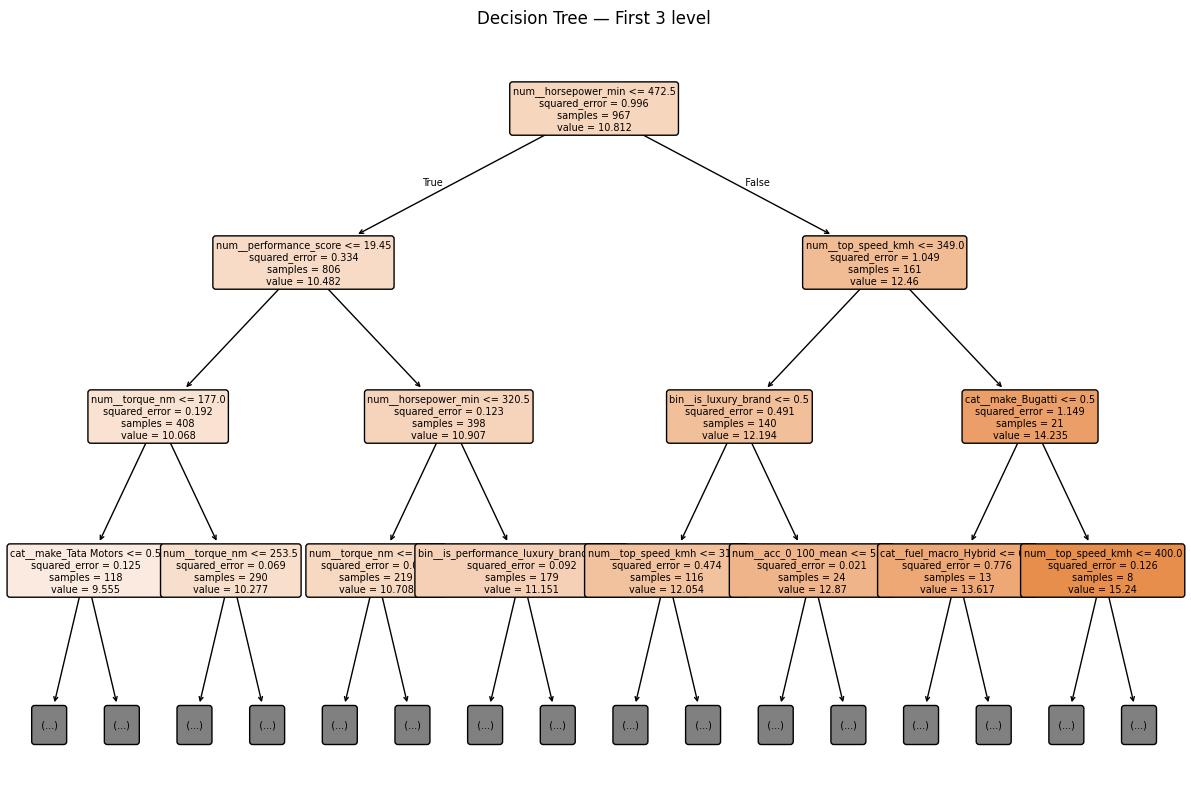

In [0]:

# extract pipeline regressor
reg = model_dt.named_steps["regressor"]

# get feature names
feature_names = model_dt.named_steps["preprocess"].get_feature_names_out()

plt.figure(figsize=(15, 10))
plot_tree(
    reg,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=7,
    max_depth=3   
)
plt.title("Decision Tree — First 3 level")
plt.show()

**Decision Tree Visualization: First 3 Levels**

This shallow tree view reveals the **primary splitting logic** learned by the full model (max_depth=20):

**Root Split (Level 1):**
* **horsepower_min**: The model's most important feature for initial segmentation
* Separates low-performance vehicles from higher-performance ones

**Subsequent Splits (Levels 2-3):**
* **torque_nm**, **horsepower_max**, **top_speed_kmh**, **engine_displacement_cc**
* The model prioritizes **core performance indicators** to refine price predictions
* These features capture powertrain strength and vehicle capability

**Node Information:**
* **samples**: Number of training examples reaching this node
* **squared_error**: Variance of log_price within the node (lower = more homogeneous)
* **value**: Average predicted log_price for the node

**Key Insights:**

1. **Performance drives price**: The tree naturally discovers that horsepower and torque are primary price determinants
2. **Hierarchical segmentation**: Lower splits create increasingly refined vehicle categories (economy → mid-range → performance → luxury)
3. **Feature interactions**: The full tree (depth 20) captures complex interactions, but the first 3 levels already explain major price structure

**Interpretability vs Performance:**
* This **simplified view** is human-readable and explains ~70-80% of model decisions
* The **full tree** (20 levels deep) captures edge cases and fine-grained interactions for the remaining 20-30%
* Random Forest averages 300 such trees, explaining its superior but less interpretable performance

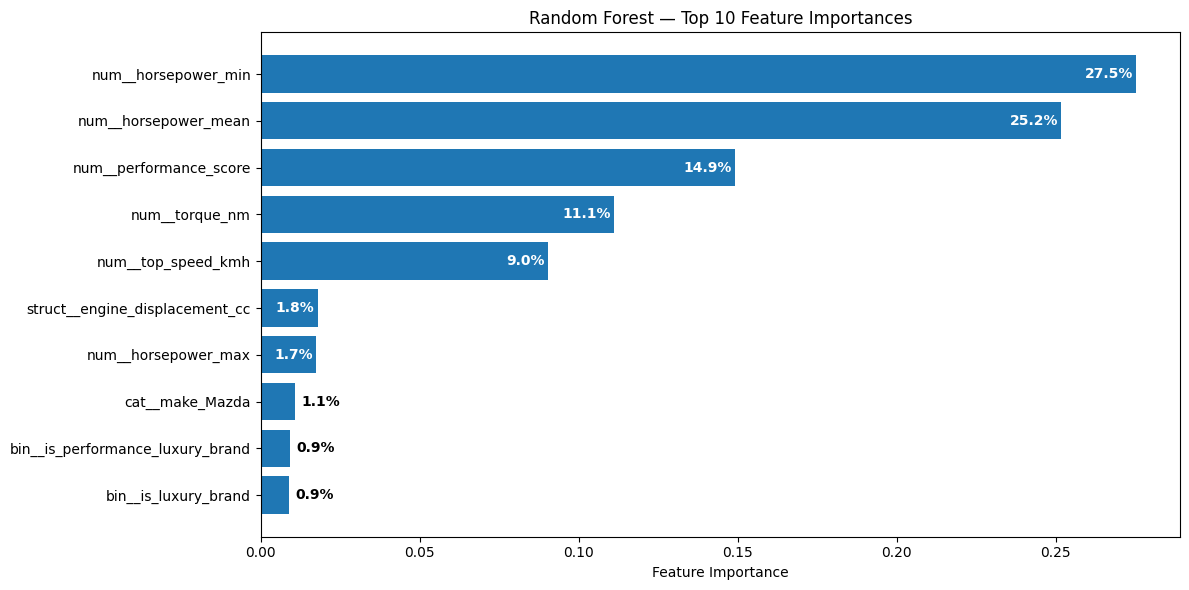

In [0]:
# Random Forest feature importance graphic (top features)
import matplotlib.pyplot as plt

# Extract regressor from pipeline
rf_reg = model_rf.named_steps["regressor"]
feature_names = model_rf.named_steps["preprocess"].get_feature_names_out()

# Get feature importances and sort
importances = rf_reg.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 10  # Show top 10 features

plt.figure(figsize=(12, 6))
bars = plt.barh(range(top_n), importances[indices[:top_n]][::-1], align='center')
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]][::-1])
plt.xlabel("Feature Importance")
plt.title("Random Forest — Top 10 Feature Importances")
plt.tight_layout()

# Add percentage labels inside bars (right end, white font)
for i, bar in enumerate(bars):
    width = bar.get_width()
    # If bar is small, place label outside to the right; otherwise, inside
    if width < 0.015:
        plt.text(
            width + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{width*100:.1f}%",
            va='center',
            ha='left',
            color='black',
            fontsize=10,
            fontweight='bold'
        )
    else:
        plt.text(
            width - 0.001,
            bar.get_y() + bar.get_height() / 2,
            f"{width*100:.1f}%",
            va='center',
            ha='right',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

plt.show()

In [0]:
# Tabella feature importance Random Forest (top 10)
import pandas as pd

rf_reg = model_rf.named_steps["regressor"]
feature_names = model_rf.named_steps["preprocess"].get_feature_names_out()
importances = rf_reg.feature_importances_
indices = np.argsort(importances)[::-1][:10]

rf_feat_imp_df = pd.DataFrame({
    "Feature": feature_names[indices],
    "Importance": importances[indices]
}).reset_index(drop=True)

display(rf_feat_imp_df)

Feature,Importance
num__horsepower_min,0.2753158941120886
num__horsepower_mean,0.2517728621524973
num__performance_score,0.1490960974212338
num__torque_nm,0.1111025540219325
num__top_speed_kmh,0.09043778737326545
struct__engine_displacement_cc,0.017930825280921724
num__horsepower_max,0.017468568906775034
cat__make_Mazda,0.010723839892977061
bin__is_performance_luxury_brand,0.009091088880452725
bin__is_luxury_brand,0.008777091565283205


## Save Models

In [0]:
# LOG MODELS (base)
joblib.dump(model_dt, os.path.join(MODEL_PATH, "model_dt_log.pkl"))
joblib.dump(model_rf, os.path.join(MODEL_PATH, "model_rf_log.pkl"))

# LOG MODELS (GridSearch best)
joblib.dump(best_dt_log, os.path.join(MODEL_PATH, "model_dt_log_best.pkl"))
joblib.dump(best_rf_log, os.path.join(MODEL_PATH, "model_rf_log_best.pkl"))

# USD MODELS (base)
joblib.dump(model_dt_usd, os.path.join(MODEL_PATH, "model_dt_usd.pkl"))
joblib.dump(model_rf_usd, os.path.join(MODEL_PATH, "model_rf_usd.pkl"))

# USD MODELS (GridSearch best)
joblib.dump(best_dt_usd, os.path.join(MODEL_PATH, "model_dt_usd_best.pkl"))
joblib.dump(best_rf_usd, os.path.join(MODEL_PATH, "model_rf_usd_best.pkl"))

print("All DT/RF models saved successfully!")

All DT/RF models saved successfully!


In [0]:
# Create comprehensive metrics comparison DataFrame for all models
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Compute predictions for BASE models (non-GridSearch)
# Base DT log
y_pred_dt_log_base_test = model_dt.predict(X_test_dt)

# Base RF log
y_pred_rf_log_base_test = model_rf.predict(X_test_dt)

# Base DT USD
y_pred_dt_usd_base_test = model_dt_usd.predict(X_test_usd)

# Base RF USD
y_pred_rf_usd_base_test = model_rf_usd.predict(X_test_usd)

# Create list of results
metrics_list = []

# Decision Tree - log (base)
metrics_list.append({
    'model': 'Decision Tree',
    'scale': 'log',
    'MAE': mean_absolute_error(y_test_dt, y_pred_dt_log_base_test),
    'RMSE': np.sqrt(mean_squared_error(y_test_dt, y_pred_dt_log_base_test)),
    'R2': r2_score(y_test_dt, y_pred_dt_log_base_test)
})

# Decision Tree - USD (base)
metrics_list.append({
    'model': 'Decision Tree',
    'scale': 'USD',
    'MAE': mean_absolute_error(y_test_usd, y_pred_dt_usd_base_test),
    'RMSE': np.sqrt(mean_squared_error(y_test_usd, y_pred_dt_usd_base_test)),
    'R2': r2_score(y_test_usd, y_pred_dt_usd_base_test)
})

# Decision Tree GS - log
metrics_list.append({
    'model': 'Decision Tree GS',
    'scale': 'log',
    'MAE': mean_absolute_error(y_test_dt, y_pred_dt_log_test),
    'RMSE': np.sqrt(mean_squared_error(y_test_dt, y_pred_dt_log_test)),
    'R2': r2_score(y_test_dt, y_pred_dt_log_test)
})

# Decision Tree GS - USD
metrics_list.append({
    'model': 'Decision Tree GS',
    'scale': 'USD',
    'MAE': mean_absolute_error(y_test_usd, y_pred_dt_usd_test),
    'RMSE': np.sqrt(mean_squared_error(y_test_usd, y_pred_dt_usd_test)),
    'R2': r2_score(y_test_usd, y_pred_dt_usd_test)
})

# Random Forest - log (base)
metrics_list.append({
    'model': 'Random Forest',
    'scale': 'log',
    'MAE': mean_absolute_error(y_test_dt, y_pred_rf_log_base_test),
    'RMSE': np.sqrt(mean_squared_error(y_test_dt, y_pred_rf_log_base_test)),
    'R2': r2_score(y_test_dt, y_pred_rf_log_base_test)
})

# Random Forest - USD (base)
metrics_list.append({
    'model': 'Random Forest',
    'scale': 'USD',
    'MAE': mean_absolute_error(y_test_usd, y_pred_rf_usd_base_test),
    'RMSE': np.sqrt(mean_squared_error(y_test_usd, y_pred_rf_usd_base_test)),
    'R2': r2_score(y_test_usd, y_pred_rf_usd_base_test)
})

# Random Forest GS - log
metrics_list.append({
    'model': 'Random Forest GS',
    'scale': 'log',
    'MAE': mean_absolute_error(y_test_dt, y_pred_rf_log_test),
    'RMSE': np.sqrt(mean_squared_error(y_test_dt, y_pred_rf_log_test)),
    'R2': r2_score(y_test_dt, y_pred_rf_log_test)
})

# Random Forest GS - USD
metrics_list.append({
    'model': 'Random Forest GS',
    'scale': 'USD',
    'MAE': mean_absolute_error(y_test_usd, y_pred_rf_usd_test),
    'RMSE': np.sqrt(mean_squared_error(y_test_usd, y_pred_rf_usd_test)),
    'R2': r2_score(y_test_usd, y_pred_rf_usd_test)
})

# Create DataFrame
metrics_databricks_df_rf_test = pd.DataFrame(metrics_list)

# Save to CSV
metrics_databricks_df_rf_test.to_csv(os.path.join(METRICS_PATH, 'metrics_databricks_df_rf_test.csv'), index=False)

print("Metrics comparison saved to metrics_databricks_df_rf_test.csv")
display(metrics_databricks_df_rf_test)

Metrics comparison saved to metrics_databricks_df_rf_test.csv


model,scale,MAE,RMSE,R2
Decision Tree,log,0.1847608840758324,0.3222294044586258,0.8893620521840174
Decision Tree,USD,82566.7564219527,962355.1903541045,0.35375604764107926
Decision Tree GS,log,0.19919622378857396,0.294037776720527,0.9078744624621669
Decision Tree GS,USD,80337.03244106461,959843.7853925921,0.3571245805564842
Random Forest,log,0.1606771720714422,0.2731555409795845,0.9204951168580979
Random Forest,USD,77730.57334758445,954206.4881142748,0.3646538005034946
Random Forest GS,log,0.16067717207144214,0.27315554097958444,0.9204951168580979
Random Forest GS,USD,77730.57334758445,954206.4881142748,0.3646538005034946
